# Setup Project Environment
Instal dan import pustaka yang dibutuhkan, pastikan versi Python serta path workspace benar.


In [1]:
import sys
from pathlib import Path
import random
import csv

import torch
import numpy as np
import pandas as pd
from ultralytics import YOLO
from tqdm import tqdm
import joblib
from PIL import Image
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from project_helpers import (
    DATASET_ANALYSIS_DIR,
    EVALUATION_DIR,
    MODEL_ARTIFACTS_DIR,
    OUTPUTS_DIR,
    RAW_INFERENCE_DIR,
    RAW_OVERLAY_DIR,
    ROOT_DIR,
    TEST_INFERENCE_DIR,
    build_cluster_interpretation,
    build_cluster_summary,
    build_feature_matrix,
    build_size_mapping,
    collect_dataset_label_boxes,
    ensure_project_dirs,
    evaluate_clustering,
    generate_size_overlays,
    list_image_records,
    reset_directory,
    save_cluster_artifacts,
    save_detection_summary,
)

print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CWD: {Path.cwd()}")
print(f"Project root: {ROOT_DIR}")


Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
PyTorch: 2.9.1+cpu
CWD: c:\Users\Alwan\Documents\GitHub\finalfixpkl
Project root: C:\Users\Alwan\Documents\GitHub\finalfixpkl


# Implement Code Fixes
Perbaikan: hapus `runs` sebelum rerun, tambah evaluasi `test`, rapikan output ke folder `artifacts` dan `outputs`, lalu gunakan anotasi ground truth seluruh dataset untuk analisis clustering agar semua sampel berlabel ikut terwakili. Inferensi `Catfish_baby_images` tetap dipisah sebagai jalur deployment.


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = 0 if torch.cuda.is_available() else "cpu"
DATASET_DIR = ROOT_DIR / "Dataset"
DATA_YAML = DATASET_DIR / "data.yaml"
DATASET_SPLITS = ("train", "valid", "test")
TEST_IMAGES_DIR = DATASET_DIR / "test" / "images"
RAW_INPUT_DIR = ROOT_DIR / "Catfish_baby_images"
RUNS_DIR = ROOT_DIR / "runs"
PROJECT_PATHS = ensure_project_dirs()

if not DATA_YAML.exists():
    raise FileNotFoundError(f"Dataset YAML tidak ditemukan: {DATA_YAML}")
if not TEST_IMAGES_DIR.exists():
    raise FileNotFoundError(f"Folder test images tidak ditemukan: {TEST_IMAGES_DIR}")

print(f"Data YAML: {DATA_YAML}")
print(f"Dataset splits: {DATASET_SPLITS}")
print(f"Test images: {TEST_IMAGES_DIR}")
print(f"Raw input: {RAW_INPUT_DIR}")
print(f"Device: {DEVICE}")
print("Output directories:")
for name, path in PROJECT_PATHS.items():
    print(f"- {name}: {path}")


Data YAML: C:\Users\Alwan\Documents\GitHub\finalfixpkl\Dataset\data.yaml
Dataset splits: ('train', 'valid', 'test')
Test images: C:\Users\Alwan\Documents\GitHub\finalfixpkl\Dataset\test\images
Raw input: C:\Users\Alwan\Documents\GitHub\finalfixpkl\Catfish_baby_images
Device: cpu
Output directories:
- artifacts: C:\Users\Alwan\Documents\GitHub\finalfixpkl\artifacts
- dataset_analysis: C:\Users\Alwan\Documents\GitHub\finalfixpkl\artifacts\dataset_analysis
- raw_inference: C:\Users\Alwan\Documents\GitHub\finalfixpkl\artifacts\raw_inference
- models: C:\Users\Alwan\Documents\GitHub\finalfixpkl\artifacts\models
- evaluation: C:\Users\Alwan\Documents\GitHub\finalfixpkl\artifacts\evaluation
- outputs: C:\Users\Alwan\Documents\GitHub\finalfixpkl\outputs
- test_inference: C:\Users\Alwan\Documents\GitHub\finalfixpkl\outputs\inference_result
- raw_overlay: C:\Users\Alwan\Documents\GitHub\finalfixpkl\outputs\final_inference_with_size


In [3]:
# Bersihkan folder runs lama agar artefak rerun tidak tercampur
if RUNS_DIR.exists():
    reset_directory(RUNS_DIR)
else:
    print("Folder runs belum ada, lanjut tanpa cleanup.")


Folder runs belum ada, lanjut tanpa cleanup.


In [4]:
# Stage 1: freeze backbone via train arg
model = YOLO("yolov8s.pt")
results_stage1 = model.train(
    data=str(DATA_YAML),
    epochs=10,
    imgsz=640,
    batch=8,
    workers=2,
    optimizer="AdamW",
    lr0=0.0006,
    lrf=0.01,
    weight_decay=0.0008,
    mosaic=0.15,
    mixup=0.10,
    copy_paste=0.10,
    hsv_h=0.015,
    hsv_s=0.6,
    hsv_v=0.4,
    scale=0.4,
    fliplr=0.5,
    freeze=list(range(10)),
    seed=SEED,
    name="train",
    exist_ok=True,
    device=DEVICE,
)


New https://pypi.org/project/ultralytics/8.4.31 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.7  Python-3.11.9 torch-2.9.1+cpu CPU (Intel Core i7-8650U 1.90GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Alwan\Documents\GitHub\finalfixpkl\Dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], half=False, hsv_h=0.015, hsv_s=0.6, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0006, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosai

In [5]:
# Stage 2: fine-tune full model
stage1_weights = RUNS_DIR / "detect" / "train" / "weights" / "last.pt"
if not stage1_weights.exists():
    raise FileNotFoundError(f"Stage-1 weights tidak ditemukan: {stage1_weights}")

model = YOLO(str(stage1_weights))
results_stage2 = model.train(
    data=str(DATA_YAML),
    epochs=60,
    imgsz=640,
    batch=8,
    workers=2,
    optimizer="AdamW",
    lr0=0.0004,
    weight_decay=0.0005,
    mosaic=0.05,
    mixup=0.05,
    copy_paste=0.05,
    scale=0.3,
    fliplr=0.5,
    flipud=0.2,
    patience=20,
    seed=SEED,
    name="train2",
    exist_ok=True,
    device=DEVICE,
)


New https://pypi.org/project/ultralytics/8.4.31 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.7  Python-3.11.9 torch-2.9.1+cpu CPU (Intel Core i7-8650U 1.90GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Alwan\Documents\GitHub\finalfixpkl\Dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0004, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=C:\Users\Alwan\Documents\GitHub\finalfixpkl\runs\detect\t

In [6]:
# Evaluation pada split valid dan test
stage2_weights = RUNS_DIR / "detect" / "train2" / "weights" / "best.pt"
if not stage2_weights.exists():
    raise FileNotFoundError(f"Stage-2 weights tidak ditemukan: {stage2_weights}")

model = YOLO(str(stage2_weights))
valid_metrics = model.val(
    data=str(DATA_YAML),
    split="val",
    device=DEVICE,
    name="valid_eval",
    exist_ok=True,
)
test_metrics = model.val(
    data=str(DATA_YAML),
    split="test",
    device=DEVICE,
    name="test_eval",
    exist_ok=True,
)

detection_summary = save_detection_summary(
    {"valid": valid_metrics, "test": test_metrics},
    EVALUATION_DIR / "detection_evaluation_summary.csv",
)
display(detection_summary)


Ultralytics 8.4.7  Python-3.11.9 torch-2.9.1+cpu CPU (Intel Core i7-8650U 1.90GHz)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 379.4200.3 MB/s, size: 117.1 KB)
val: Scanning C:\Users\Alwan\Documents\GitHub\finalfixpkl\Dataset\valid\labels.cache... 70 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 70/70  0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 101. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 4.6s/it 22.9s7.2ss
                   all         70        101      0.868      0.977      0.978      0.821
Speed: 2.0ms preprocess, 295.7ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to C:\Users\Al

,split,precision,recall,mAP50,mAP50_95,fitness,save_dir
0,valid,0.868033,0.976901,0.977522,0.821466,0.821466,C:\Users\Alwan\Documents\GitHub\finalfixpkl\ru...
1,test,0.907190,0.942142,0.950885,0.748818,0.748818,C:\Users\Alwan\Documents\GitHub\finalfixpkl\ru...


# Run and Verify Unit Tests
Jalankan inferensi singkat dan pastikan hasil batch inferensi tersimpan di dalam folder `outputs`.



image 1/1 C:\Users\Alwan\Documents\GitHub\finalfixpkl\Dataset\test\images\037_jpg.rf.7d255f306d9e7d1c022f4028e02f2b76.jpg: 640x384 1 lele, 240.3ms
Speed: 4.2ms preprocess, 240.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 384)


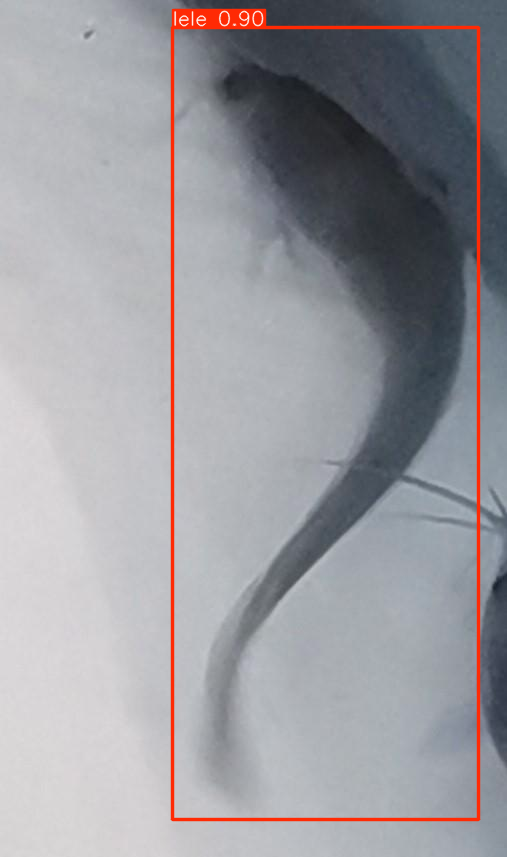

Sanity inference done untuk: 037_jpg.rf.7d255f306d9e7d1c022f4028e02f2b76.jpg


In [7]:
# Quick sanity inference pada satu gambar test
test_candidates = sorted(
    path for path in TEST_IMAGES_DIR.iterdir()
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
)
if not test_candidates:
    raise FileNotFoundError(f"Tidak ada gambar test pada {TEST_IMAGES_DIR}")

test_img = test_candidates[0]
model = YOLO(str(stage2_weights))
res = model(str(test_img), conf=0.25, device=DEVICE)
for result in res:
    display(Image.fromarray(result.plot()))
print(f"Sanity inference done untuk: {test_img.name}")


In [8]:
# Inference batch test ke folder outputs/inference_result
input_folder = TEST_IMAGES_DIR
inference_output = TEST_INFERENCE_DIR
if inference_output.exists():
    reset_directory(inference_output)
else:
    print("Folder inference_result belum ada, akan dibuat saat inferensi.")

results = model.predict(
    source=str(input_folder),
    save=True,
    project=str(OUTPUTS_DIR),
    name=inference_output.name,
    conf=0.25,
    exist_ok=True,
    device=DEVICE,
)
print("Inference batch selesai. Folder:", inference_output)


Removed existing folder: C:\Users\Alwan\Documents\GitHub\finalfixpkl\outputs\inference_result

image 1/140 C:\Users\Alwan\Documents\GitHub\finalfixpkl\Dataset\test\images\037_jpg.rf.7d255f306d9e7d1c022f4028e02f2b76.jpg: 640x384 1 lele, 198.3ms
image 2/140 C:\Users\Alwan\Documents\GitHub\finalfixpkl\Dataset\test\images\041_jpg.rf.cb44e1be09bfa485c21620577b97d1c5.jpg: 640x544 2 leles, 373.0ms
image 3/140 C:\Users\Alwan\Documents\GitHub\finalfixpkl\Dataset\test\images\051_jpg.rf.f8d1a208a637cb87a4d7ad6e4727f184.jpg: 640x288 1 lele, 224.5ms
image 4/140 C:\Users\Alwan\Documents\GitHub\finalfixpkl\Dataset\test\images\055_jpg.rf.29920056d02b3c67a87d9f822a2789cd.jpg: 416x640 1 lele, 255.2ms
image 5/140 C:\Users\Alwan\Documents\GitHub\finalfixpkl\Dataset\test\images\056_jpg.rf.90f4ed316fbfaaa121c92789245ff3f6.jpg: 352x640 1 lele, 212.1ms
image 6/140 C:\Users\Alwan\Documents\GitHub\finalfixpkl\Dataset\test\images\058_jpg.rf.e2e0d76fc165e2a345aa9adc17a78cfb.jpg: 640x480 5 leles, 312.9ms
image 7/1

# Dataset-Wide Clustering Preparation
Untuk memastikan seluruh sampel berlabel terwakili dalam analisis ukuran, tahap clustering memakai bounding box anotasi ground truth dari seluruh dataset (`train`, `valid`, `test`).


In [9]:
# Kumpulkan seluruh bounding box dataset dari label ground truth
DATASET_BOXES_CSV = DATASET_ANALYSIS_DIR / "dataset_boxes_all.csv"
dataset_boxes_df = collect_dataset_label_boxes(DATASET_DIR, DATASET_SPLITS)
dataset_boxes_df.to_csv(DATASET_BOXES_CSV, index=False)

print("Box dataset penuh disimpan di:", DATASET_BOXES_CSV)
display(
    dataset_boxes_df.groupby("source_split")
    .size()
    .rename("box_count")
    .reset_index()
)
display(dataset_boxes_df.head())


Box dataset penuh disimpan di: C:\Users\Alwan\Documents\GitHub\finalfixpkl\artifacts\dataset_analysis\dataset_boxes_all.csv


,source_split,box_count
0,test,249
1,train,2081
2,valid,101


,source_split,filename,filepath,label_path,annotation_index,class_id,box_source,x1,y1,x2,y2,width_px,height_px
0,train,184_jpg.rf.e084c2d1d6e4f0e63f9fa697b0f39c9a.jpg,C:\Users\Alwan\Documents\GitHub\finalfixpkl\Da...,C:\Users\Alwan\Documents\GitHub\finalfixpkl\Da...,0,0,ground_truth_label,120.030,174.565,1065.630,444.875,945.60,270.31
1,train,184_jpg.rf.e084c2d1d6e4f0e63f9fa697b0f39c9a.jpg,C:\Users\Alwan\Documents\GitHub\finalfixpkl\Da...,C:\Users\Alwan\Documents\GitHub\finalfixpkl\Da...,1,0,ground_truth_label,440.035,196.570,1287.805,658.370,847.77,461.80
2,train,185_jpg.rf.28fec1139bc2217615fc0c26f8b9055b.jpg,C:\Users\Alwan\Documents\GitHub\finalfixpkl\Da...,C:\Users\Alwan\Documents\GitHub\finalfixpkl\Da...,0,0,ground_truth_label,152.030,140.570,1104.870,717.990,952.84,577.42
3,train,185_jpg.rf.28fec1139bc2217615fc0c26f8b9055b.jpg,C:\Users\Alwan\Documents\GitHub\finalfixpkl\Da...,C:\Users\Alwan\Documents\GitHub\finalfixpkl\Da...,1,0,ground_truth_label,130.035,62.570,804.205,629.030,674.17,566.46
4,train,185_jpg.rf.28fec1139bc2217615fc0c26f8b9055b.jpg,C:\Users\Alwan\Documents\GitHub\finalfixpkl\Da...,C:\Users\Alwan\Documents\GitHub\finalfixpkl\Da...,2,0,ground_truth_label,28.035,156.570,724.225,649.790,696.19,493.22


In [10]:
# Ekstraksi fitur ukuran
FEATURES_NPY = DATASET_ANALYSIS_DIR / "features_all_dataset.npy"
dataset_boxes_df = pd.read_csv(DATASET_ANALYSIS_DIR / "dataset_boxes_all.csv")
feature_df, X = build_feature_matrix(dataset_boxes_df)
np.save(FEATURES_NPY, X)
print("Fitur disimpan ke:", FEATURES_NPY, "Shape:", X.shape)
display(feature_df[["filename", "area_px", "diag_px", "aspect_ratio"]].head())


Fitur disimpan ke: C:\Users\Alwan\Documents\GitHub\finalfixpkl\artifacts\dataset_analysis\features_all_dataset.npy Shape: (2431, 3)


,filename,area_px,diag_px,aspect_ratio
0,184_jpg.rf.e084c2d1d6e4f0e63f9fa697b0f39c9a.jpg,255605.1360,983.476922,3.498206
1,184_jpg.rf.e084c2d1d6e4f0e63f9fa697b0f39c9a.jpg,391500.1860,965.387597,1.835795
2,185_jpg.rf.28fec1139bc2217615fc0c26f8b9055b.jpg,550188.8728,1114.144480,1.650168
3,185_jpg.rf.28fec1139bc2217615fc0c26f8b9055b.jpg,381890.3382,880.557846,1.190146
4,185_jpg.rf.28fec1139bc2217615fc0c26f8b9055b.jpg,343374.8318,853.197799,1.411520


In [11]:
# Scaling + KMeans + evaluasi clustering
FEATURES_NPY = DATASET_ANALYSIS_DIR / "features_all_dataset.npy"
SCALER_PATH = MODEL_ARTIFACTS_DIR / "scaler_kmeans.pkl"
KMEANS_PATH = MODEL_ARTIFACTS_DIR / "kmeans_size.pkl"

X = np.load(FEATURES_NPY)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, SCALER_PATH)

kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
joblib.dump(kmeans, KMEANS_PATH)

clustering_metrics = evaluate_clustering(X_scaled, clusters)
cluster_counts = (
    pd.Series(clusters)
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)

display(clustering_metrics)
display(cluster_counts)
print("Scaling & KMeans selesai. Center (scaled):")
print(kmeans.cluster_centers_)


,n_samples,n_clusters,silhouette_score,davies_bouldin_score,calinski_harabasz_score,largest_cluster_share,smallest_cluster_share
0,2431,3,0.42394,0.795584,2031.342689,0.510078,0.190868


,cluster,count
0,0,1240
1,1,727
2,2,464


Scaling & KMeans selesai. Center (scaled):
[[    0.70275     0.57596    -0.41567]
 [    -1.0183     -1.2079    -0.36841]
 [   -0.27669     0.35772      1.6834]]


In [12]:
# Mapping cluster -> label + interpretasi clustering
dataset_boxes_df = pd.read_csv(DATASET_ANALYSIS_DIR / "dataset_boxes_all.csv")
feature_df, X = build_feature_matrix(dataset_boxes_df)
scaler = joblib.load(MODEL_ARTIFACTS_DIR / "scaler_kmeans.pkl")
kmeans = joblib.load(MODEL_ARTIFACTS_DIR / "kmeans_size.pkl")
clusters = kmeans.predict(scaler.transform(X))

dataset_boxes_df["cluster"] = clusters
dataset_boxes_df["area_px"] = feature_df["area_px"]
mapping = build_size_mapping(dataset_boxes_df)
dataset_boxes_df["size_class"] = dataset_boxes_df["cluster"].map(mapping)
classified_path = DATASET_ANALYSIS_DIR / "classified_sizes_all_dataset.csv"
dataset_boxes_df.to_csv(classified_path, index=False)

cluster_summary = build_cluster_summary(dataset_boxes_df)
clustering_metrics = evaluate_clustering(scaler.transform(X), clusters)
interpretation_lines = build_cluster_interpretation(cluster_summary)
artifact_paths = save_cluster_artifacts(
    cluster_summary,
    clustering_metrics,
    interpretation_lines,
    EVALUATION_DIR,
)

print("Cluster mapping:", mapping)
display(cluster_summary)
if "source_split" in dataset_boxes_df.columns:
    display(
        dataset_boxes_df.groupby(["source_split", "size_class"])
        .size()
        .rename("count")
        .reset_index()
    )
print("Interpretasi hasil clustering:")
for line in interpretation_lines:
    print("-", line)
print("File utama tersimpan:", classified_path)
print("Artefak clustering:", artifact_paths)


Cluster mapping: {1: 'Fries', 2: 'Fingerling', 0: 'Juvenile'}


,cluster,size_class,sample_count,mean_width_px,mean_height_px,mean_area_px,median_area_px,min_area_px,max_area_px,mean_diag_px,mean_aspect_ratio,share
0,1,Fries,727,421.260083,513.157744,207261.794889,212855.90520,47077.0030,339680.4200,685.589761,0.948475,0.299054
1,2,Fingerling,464,904.368060,338.593060,306572.829617,308308.22795,145109.6504,509091.8694,968.148171,2.779434,0.190868
2,0,Juvenile,1240,613.284048,759.618589,438270.977920,428439.05470,238269.5367,841640.8518,1007.838636,0.908431,0.510078


,source_split,size_class,count
0,test,Fingerling,66
1,test,Fries,99
2,test,Juvenile,84
3,train,Fingerling,381
4,train,Fries,595
5,train,Juvenile,1105
6,valid,Fingerling,17
7,valid,Fries,33
8,valid,Juvenile,51


Interpretasi hasil clustering:
- Urutan ukuran berdasarkan rata-rata area adalah Fries (cluster 1) < Fingerling (cluster 2) < Juvenile (cluster 0).
- Fries pada cluster 1 mencakup 727 deteksi (29.9%) dengan rata-rata area 207,262 px2, median 212,856 px2, rentang 47,077-339,680 px2, dan bounding box relatif seimbang antara lebar dan tinggi.
- Fingerling pada cluster 2 mencakup 464 deteksi (19.1%) dengan rata-rata area 306,573 px2, median 308,308 px2, rentang 145,110-509,092 px2, dan bounding box cenderung lebih melebar secara horizontal.
- Juvenile pada cluster 0 mencakup 1240 deteksi (51.0%) dengan rata-rata area 438,271 px2, median 428,439 px2, rentang 238,270-841,641 px2, dan bounding box relatif seimbang antara lebar dan tinggi.
File utama tersimpan: C:\Users\Alwan\Documents\GitHub\finalfixpkl\artifacts\dataset_analysis\classified_sizes_all_dataset.csv
Artefak clustering: {'summary_csv': WindowsPath('C:/Users/Alwan/Documents/GitHub/finalfixpkl/artifacts/evaluation/cluster_interpreta

In [13]:
# Inferensi dan klasifikasi ukuran untuk Catfish_baby_images
RAW_DETECTIONS_CSV = RAW_INFERENCE_DIR / "detections_raw_images.csv"
RAW_CLASSIFIED_CSV = RAW_INFERENCE_DIR / "classified_sizes_raw_images.csv"
raw_image_index = list_image_records(RAW_INPUT_DIR, source_name="raw_images")
raw_paths = raw_image_index["filepath"].tolist()
raw_split_lookup = dict(zip(raw_image_index["filepath"], raw_image_index["source_split"]))

model = YOLO(str(stage2_weights))
raw_results = model.predict(
    source=str(RAW_INPUT_DIR),
    conf=0.25,
    stream=True,
    device=DEVICE,
    imgsz=640,
    half=True if DEVICE != "cpu" else False,
    batch=1,
)

wrote_any = False
detected_raw_paths = set()
with RAW_DETECTIONS_CSV.open("w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(
        file,
        fieldnames=[
            "source_split",
            "filename",
            "filepath",
            "x1",
            "y1",
            "x2",
            "y2",
            "width_px",
            "height_px",
        ],
    )
    writer.writeheader()

    for result in tqdm(raw_results, total=len(raw_paths), desc="Running raw-image inference"):
        resolved_path = str(Path(result.path).resolve())
        if result.boxes is None or len(result.boxes) == 0:
            continue
        detected_raw_paths.add(resolved_path)
        for box in result.boxes:
            xyxy = box.xyxy[0].cpu().numpy()
            x1, y1, x2, y2 = [float(value) for value in xyxy]
            width, height = x2 - x1, y2 - y1
            writer.writerow(
                {
                    "source_split": raw_split_lookup.get(resolved_path, "raw_images"),
                    "filename": Path(result.path).name,
                    "filepath": resolved_path,
                    "x1": x1,
                    "y1": y1,
                    "x2": x2,
                    "y2": y2,
                    "width_px": width,
                    "height_px": height,
                }
            )
            wrote_any = True

if not wrote_any:
    raise ValueError("Tidak ada deteksi pada Catfish_baby_images.")

raw_detections_df = pd.read_csv(RAW_DETECTIONS_CSV)
raw_feature_df, raw_X = build_feature_matrix(raw_detections_df)
scaler = joblib.load(MODEL_ARTIFACTS_DIR / "scaler_kmeans.pkl")
kmeans = joblib.load(MODEL_ARTIFACTS_DIR / "kmeans_size.pkl")
mapping = (
    pd.read_csv(DATASET_ANALYSIS_DIR / "classified_sizes_all_dataset.csv")[["cluster", "size_class"]]
    .drop_duplicates()
    .sort_values("cluster")
    .set_index("cluster")["size_class"]
    .to_dict()
)
raw_clusters = kmeans.predict(scaler.transform(raw_X))

raw_detections_df["cluster"] = raw_clusters
raw_detections_df["area_px"] = raw_feature_df["area_px"]
raw_detections_df["size_class"] = raw_detections_df["cluster"].map(mapping)
raw_detections_df.to_csv(RAW_CLASSIFIED_CSV, index=False)

print("Deteksi raw images tersimpan di:", RAW_DETECTIONS_CSV)
print("Klasifikasi raw images tersimpan di:", RAW_CLASSIFIED_CSV)
print(f"Gambar raw dengan minimal 1 deteksi: {len(detected_raw_paths)} dari {len(raw_paths)}")


Running raw-image inference:   0%|          | 0/753 [00:00<?, ?it/s]


image 1/753 C:\Users\Alwan\Documents\GitHub\finalfixpkl\Catfish_baby_images\001.jpg: 640x384 1 lele, 260.3ms


Running raw-image inference:   0%|          | 1/753 [00:00<04:17,  2.92it/s]

image 2/753 C:\Users\Alwan\Documents\GitHub\finalfixpkl\Catfish_baby_images\002.jpg: 288x640 1 lele, 144.0ms


Running raw-image inference:   0%|          | 2/753 [00:00<03:04,  4.07it/s]

...

image 753/753 C:\Users\Alwan\Documents\GitHub\finalfixpkl\Catfish_baby_images\IMG_20231103_222738.jpg: 480x640 13 leles, 238.0ms


Running raw-image inference: 100%|██████████| 753/753 [05:02<00:00,  1.54it/s]

Speed: 9.9ms preprocess, 284.1ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


Running raw-image inference: 100%|██████████| 753/753 [05:02<00:00,  2.49it/s]


Deteksi raw images tersimpan di: C:\Users\Alwan\Documents\GitHub\finalfixpkl\artifacts\raw_inference\detections_raw_images.csv
Klasifikasi raw images tersimpan di: C:\Users\Alwan\Documents\GitHub\finalfixpkl\artifacts\raw_inference\classified_sizes_raw_images.csv
Gambar raw dengan minimal 1 deteksi: 753 dari 753


In [14]:
# Generate overlay dengan label ukuran untuk Catfish_baby_images
OUTPUT_FOLDER = RAW_OVERLAY_DIR
classified_df = pd.read_csv(RAW_INFERENCE_DIR / "classified_sizes_raw_images.csv")
output_folder, missing_images = generate_size_overlays(
    classified_df,
    OUTPUT_FOLDER,
    clear_existing=True,
)
print("Overlay selesai. Folder:", output_folder)
print("Jumlah gambar yang gagal dibaca:", missing_images)


Overlay selesai. Folder: C:\Users\Alwan\Documents\GitHub\finalfixpkl\outputs\final_inference_with_size
Jumlah gambar yang gagal dibaca: 0
